# __Main_part__

__Connecting and import libraries__

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.neighbors import kneighbors_graph
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
from IPython.display import display, Markdown
from IPython.core.display import display, HTML
import time
from tabulate import tabulate
from sklearn.mixture import GaussianMixture
from scipy.stats import multivariate_normal
print(torch.cuda.is_available())

False


__Task_1 - Theory__

- **Propose a new method to initialize cluster centroids for K-means. List the advantages and disadvantages of Forgy, Random Partition, and your own initializations.** \
\
Common disadvantage of all methods:
The "correct" number of clusters k is unknown - it must be specified in advance.

1. __Forgy method__ \
_Advantage_: very simple and fast (random points are selected from the data). \
_Disadvantage_: the selected centers may be too close to each other, which will lead to an unsuccessful partition.

2. __Random Partition method__ \
_Advantage_: due to the random distribution of objects between clusters, the centers are calculated as group averages, which often gives a more uniform initial distribution. \
_Disadvantage_: the centers may be "smeared" (i.e. lie in areas where there are actually few data points), and then the first iterations will be spent on "pulling" the centers into the right places.

3. __Proposed method__: Geometric placement of centers \
Idea: For a given number of clusters k, a regular figure is constructed (for example, a square for k = 4, a triangle for k = 3, a regular polygon for large k). The centers are initialized at the vertices of this shape, located in the center of the data region.
_Advantages_: It is guaranteed that the centers are far from each other (unlike Forgy). The initial configuration is symmetrical → less risk that all the centers will "collapse" into one part of the data.
_Disadvantages_: The centers do not necessarily coincide with real objects (unlike Forgy). If the data distribution is very uneven, the selected positions may end up in empty areas.

- **Describe how you can use clustering to speed up the KNN model. Hint: what is kd-tree?** \
\
The problem of classical KNN: In the "head-on" implementation of KNN, for each new object, the distance to all n points of the training sample must be calculated. This gives a complexity of O(n d) (where d is the dimension of the features).
\
The idea of acceleration through the data structure: If you "organize" the space of points in advance, then when searching for the nearest neighbors, you do not need to check all the objects. One way is to use a partition tree (for example, kd-tree), which is similar to hierarchical clustering of space.
\
Relationship with clustering \
Construction of a kd-tree can be considered a special case of "hard clustering":
first, the data is divided by one coordinate into 2 subsets (two clusters),
then each subset is divided again (by another coordinate), and so on recursively. As a result, the points are grouped by regions, and the search for the nearest neighbor is reduced to traversing only those "clusters" that can contain the answer.
\
Complexity: Thanks to this "clustering-space", the KNN algorithm runs on average in O(log n) instead of O(n), which is similar to binary search. But in the worst case (e.g., with high dimensions), the complexity can again be close to O(n) - this is the "curse of dimensionality".

__Task_2 - Preprocessing__

Import data

In [4]:
df_train = pd.read_json("drive/MyDrive/Colab_Notebooks/s21_ML7/train.json")
print(df_train.shape)
df_train.head(2)

(49352, 15)


,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low


In [5]:
df_test = pd.read_json("drive/MyDrive/Colab_Notebooks/s21_ML7/test.json")
print(df_test.shape)
df_test.head(2)

(74659, 14)


,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address
0,1.0,1,79780be1514f645d7e6be99a3de696c5,2016-06-11 05:29:41,Large with awesome terrace--accessible via bed...,Suffolk Street,"[Elevator, Laundry in Building, Laundry in Uni...",40.7185,7142618,-73.9865,b1b1852c416d78d7765d746cb1b8921f,[https://photos.renthop.com/2/7142618_1c45a2c8...,2950,99 Suffolk Street
1,1.0,2,0,2016-06-24 06:36:34,Prime Soho - between Bleecker and Houston - Ne...,Thompson Street,"[Pre-War, Dogs Allowed, Cats Allowed]",40.7278,7210040,-74.0000,d0b5648017832b2427eeb9956d966a14,[https://photos.renthop.com/2/7210040_d824cc71...,2850,176 Thompson Street


Label encoder for feature "interest_level"

In [6]:
df_train["interest_level"].unique()

array(['medium', 'low', 'high'], dtype=object)

In [7]:
labels = df_train["interest_level"]
encoder = LabelEncoder()
df_train["interest_level_encoded"] = encoder.fit_transform(labels)
label_mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
df_train.drop('interest_level', axis=1, inplace=True)

In [8]:
df_train["interest_level_encoded"].unique()

array([2, 1, 0])

Creating features: 'Elevator', 'HardwoodFloors', 'CatsAllowed', 'DogsAllowed', 'Doorman', 'Dishwasher', 'NoFee', 'LaundryinBuilding', 'FitnessCenter', 'Pre-War', 'LaundryinUnit', 'RoofDeck', 'OutdoorSpace', 'DiningRoom', 'HighSpeedInternet', 'Balcony', 'SwimmingPool', 'LaundryInBuilding', 'NewConstruction', 'Terrace'.

In [9]:
df_train["features"] = df_train["features"].apply(
    lambda feats: [feat.replace(" ", "").lower() for feat in feats]
)

In [10]:
df_train.sample(2)

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level_encoded
45641,1.0,1,300d27d8ba2adbcbc8c6f2bcbc1c6f9d,2016-05-15 04:58:31,,East 16th Street,"[elevator, catsallowed, dogsallowed, exclusive]",40.7348,7016785,-73.9865,d1737922fe92ccb0dc37ba85589e6415,[https://photos.renthop.com/2/7016785_c74089a9...,3900,145 East 16th Street,1
52030,1.0,1,50ba0704018ed3474ed1a193d55a3b3d,2016-05-28 02:32:30,This gorgeous 1 bedroom in beautiful pre-war b...,W 164 Street,[hardwoodfloors],40.8388,7078354,-73.9428,119d9b577a2506cd7348d01fd5d0830b,[https://photos.renthop.com/2/7078354_82b32d75...,1695,618 W 164 Street,2


In [11]:
df_train["features"] = df_train["features"].apply(
    lambda feats: [feat.replace(" ", "").lower() for feat in feats]
)

target_features = [
    'Elevator', 'HardwoodFloors', 'CatsAllowed', 'DogsAllowed', 'Doorman',
    'Dishwasher', 'NoFee', 'LaundryinBuilding', 'FitnessCenter', 'Pre-War',
    'LaundryinUnit', 'RoofDeck', 'OutdoorSpace', 'DiningRoom',
    'HighSpeedInternet', 'Balcony', 'SwimmingPool', 'NewConstruction', 'Terrace']

target_features = [f.replace(" ", "").lower() for f in target_features]

for feat in target_features:
    df_train[feat] = df_train["features"].apply(lambda feats: int(feat in feats))

df_train.drop("features", axis=1, inplace=True)

In [12]:
print(df_train.shape)
df_train.sample(2)

(49352, 33)


,bathrooms,bedrooms,building_id,created,description,display_address,latitude,listing_id,longitude,manager_id,...,pre-war,laundryinunit,roofdeck,outdoorspace,diningroom,highspeedinternet,balcony,swimmingpool,newconstruction,terrace
98516,1.0,1,2845fb96ab089878b3dbfa36555ff4df,2016-04-19 02:14:37,This beautiful apartment is located in a full-...,Riverside Boulevard,40.7784,6891924,-73.9880,ad83b7286b71237e69196a8c3275a904,...,0,1,0,0,0,0,0,0,0,0
58276,1.0,2,f4fce2be9d94d6ee2f4449db343ff8e4,2016-05-05 05:20:39,Cant beat this deal!! Exquisite flex 2bd (real...,East 95th Street,40.7844,6969322,-73.9497,be1a7235af23dd77d0d1029dd5bfa5e9,...,1,0,1,0,0,1,0,1,0,0


In [13]:
df_test["features"] = df_test["features"].apply(
    lambda feats: [feat.replace(" ", "").lower() for feat in feats]
)

target_features = [f.replace(" ", "").lower() for f in target_features]

for feat in target_features:
    df_test[feat] = df_test["features"].apply(lambda feats: int(feat in feats))

df_test.drop("features", axis=1, inplace=True)

In [14]:
print(df_test.shape)

(74659, 32)


__Task_3 - KMeans__

Implementation of custom K-Means algorithm

In [15]:
class CustomKMeans:
    def __init__(self, n_clusters=3, max_iter=300, tol=1e-4, random_state=None, init="k-means++"):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.init = init
        self.cluster_centers_ = None
        self.inertia_ = None
        self.labels_ = None

    def _init_centroids(self, X):
        np.random.seed(self.random_state)
        n_samples, _ = X.shape

        if self.init == "random":
            indices = np.random.choice(n_samples, self.n_clusters, replace=False)
            return X[indices]

        elif self.init == "k-means++":
            centroids = []
            idx = np.random.randint(n_samples)
            centroids.append(X[idx])

            for _ in range(1, self.n_clusters):
                dist_sq = np.min(
                    [np.linalg.norm(X - c, axis=1) ** 2 for c in centroids],
                    axis=0
                )
                probs = dist_sq / dist_sq.sum()
                idx = np.random.choice(n_samples, p=probs)
                centroids.append(X[idx])

            return np.array(centroids)

    def fit(self, X):
        # 1step: инициализация центров (рандом или умная)
        X = np.array(X)
        centroids = self._init_centroids(X)

        for _ in range(self.max_iter):
            # 2step: относим каждую точку к какому-то лэйблу как минимум до центров
            labels = np.argmin(
                np.linalg.norm(X[:, np.newaxis] - centroids, axis=2), axis=1
            )
            # 3step: смещение центров как среднее всех точек под этим лэйблом
            new_centroids = []
            for i in range(self.n_clusters):
              points_in_cluster = X[labels == i]
              if len(points_in_cluster) > 0:
                new_center = points_in_cluster.mean(axis=0)
              else:
                new_center = centroids[i]
              new_centroids.append(new_center)
            new_centroids = np.array(new_centroids)

            # Если смещение мало - выходим
            if np.linalg.norm(new_centroids - centroids) < self.tol: break
            centroids = new_centroids

        # 4step: обновление параметров
        self.cluster_centers_ = centroids
        self.labels_ = labels
        self.inertia_ = np.sum(
            [np.linalg.norm(X[i] - centroids[labels[i]]) ** 2 for i in range(len(X))]
        )
        return self

    def predict(self, X):
        X = np.array(X)
        return np.argmin(
            np.linalg.norm(X[:, np.newaxis] - self.cluster_centers_, axis=2), axis=1
        )

Visualization

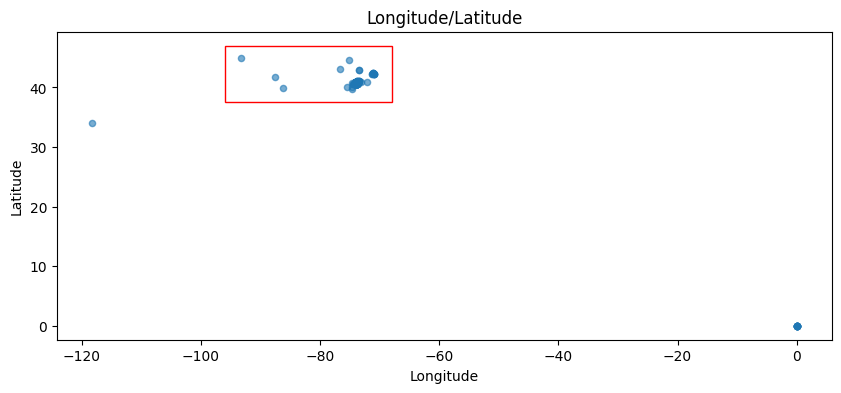

In [16]:
plt.figure(figsize=(10, 4))

plt.scatter(
    df_train['longitude'],
    df_train['latitude'],
    cmap='tab20',
    s=20,
    alpha=0.6
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Longitude/Latitude")

x_min, x_max = -96, -68
y_min, y_max = 37.5, 47

rect = patches.Rectangle(
    (x_min, y_min),
    x_max - x_min,
    y_max - y_min,
    linewidth=1,
    edgecolor='red',
    facecolor='none'
)
plt.gca().add_patch(rect)

plt.show()

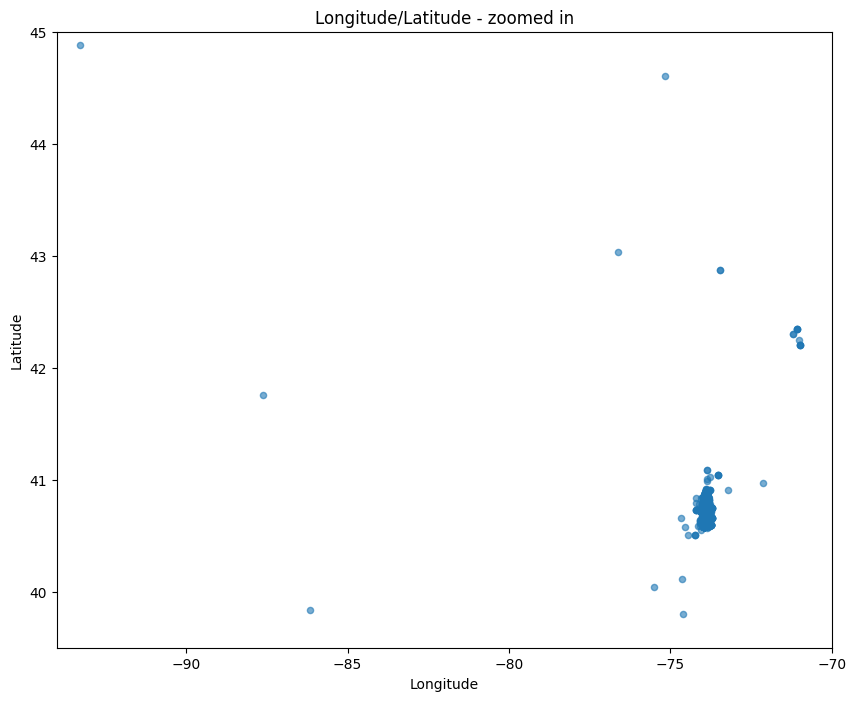

In [17]:
plt.figure(figsize=(10, 8))

plt.scatter(
    df_train['longitude'],
    df_train['latitude'],
    cmap='tab20',
    s=20,
    alpha=0.6
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Longitude/Latitude - zoomed in")

plt.xlim(-94, -70)
plt.ylim(39.5, 45)

plt.show()

CustomKMeans by longitude, latitude

In [18]:
lon_min, lon_max = -74.5, -73.5
lat_min, lat_max = 40.4, 41.2

df_train_filtered = df_train[
    (df_train["longitude"] >= lon_min) &
    (df_train["longitude"] <= lon_max) &
    (df_train["latitude"]  >= lat_min) &
    (df_train["latitude"]  <= lat_max)
].copy()

print(f"Before filtration: {df_train.shape[0]}")
print(f"After filtration: {df_train_filtered.shape[0]}")

Before filtration: 49352
After filtration: 49314


In [19]:
start = time.time()
kmeans = CustomKMeans(n_clusters=30, random_state=42)
kmeans.fit(df_train_filtered[['longitude', 'latitude']])
end = time.time()

df_train_filtered['cluster'] = kmeans.predict(df_train_filtered[['longitude', 'latitude']])
print("KMeans time:", end - start)

KMeans time: 2.949040651321411


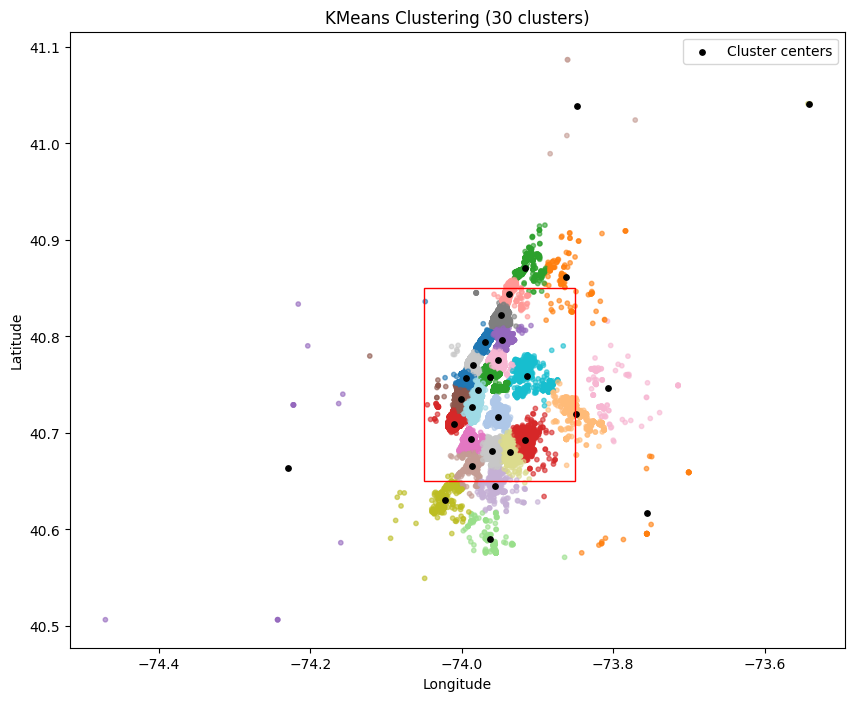

In [20]:
plt.figure(figsize=(10, 8))

plt.scatter(
    df_train_filtered['longitude'],
    df_train_filtered['latitude'],
    c=df_train_filtered['cluster'],
    cmap='tab20',
    s=10,
    alpha=0.6
)

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    c='black',
    s=15,
    marker='o',
    label='Cluster centers'
)

x_min, x_max = -74.05, -73.85
y_min, y_max = 40.65, 40.85

rect = patches.Rectangle(
    (x_min, y_min),
    x_max - x_min,
    y_max - y_min,
    linewidth=1,
    edgecolor='red',
    facecolor='none'
)
plt.gca().add_patch(rect)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("KMeans Clustering (30 clusters)")
plt.legend()
plt.show()

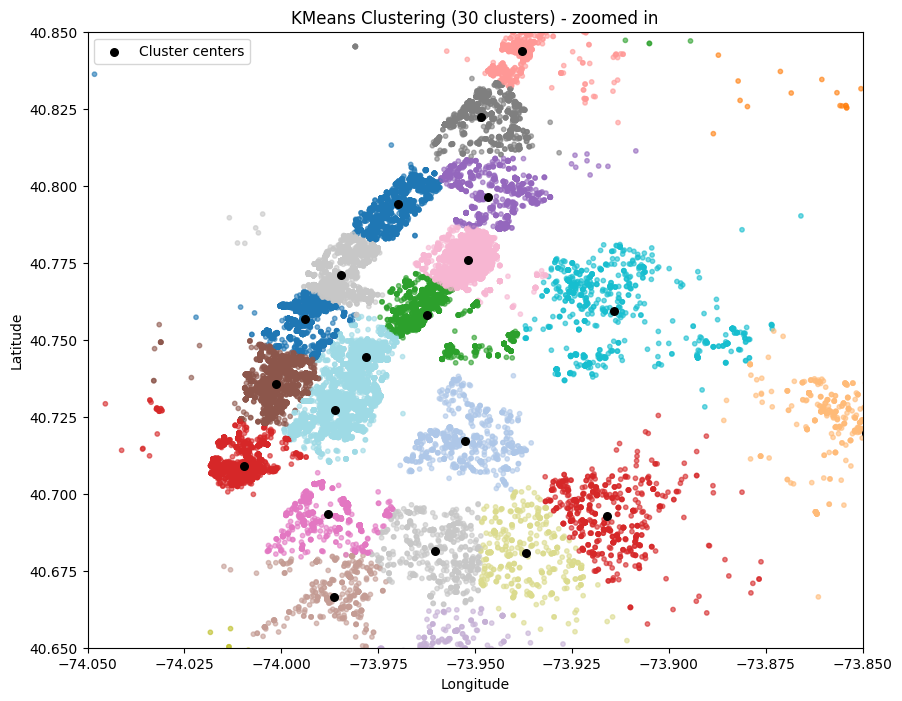

In [21]:
plt.figure(figsize=(10, 8))

plt.scatter(
    df_train_filtered['longitude'],
    df_train_filtered['latitude'],
    c=df_train_filtered['cluster'],
    cmap='tab20',
    s=10,
    alpha=0.6
)

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    c='black',
    s=30,
    marker='o',
    label='Cluster centers'
)

plt.xlim(-74.05, -73.85)
plt.ylim(40.65, 40.85)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("KMeans Clustering (30 clusters) - zoomed in")
plt.legend()
plt.show()

In [22]:
distortion = kmeans.inertia_
display(Markdown(f"**Distortion: {distortion:.2f}**"))

sil_score = silhouette_score(df_train_filtered[['longitude', 'latitude']], df_train_filtered["cluster"])
display(Markdown(f"**Silhouette Score: {sil_score:.2f}**"))

**Distortion: 4.27**

**Silhouette Score: 0.48**

Lasso for prediction "Price" (20 features + "cluster" + "interest_level" + "badrooms" + "bathrooms")

In [23]:
X_train = df_train_filtered.drop(["building_id", "created", "description", "display_address", "latitude", "listing_id",
                                  "longitude", "manager_id", "photos", "price", "street_address"], axis=1).fillna(-1)
y_train = df_train_filtered["price"]

In [24]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)

In [25]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

y_pred = lasso.predict(X_train_scaled)

In [26]:
coefs = lasso.coef_

feature_importance = pd.DataFrame({
    "name": X_train.columns,
    "importance": abs(coefs)
}).sort_values(by="importance", key=abs, ascending=True)

feature_importance.set_index("name", inplace=True)
(
    feature_importance
    .style
    .apply(
        lambda row: ['color: yellow' if row.name == "cluster" else '' for _ in row],
        axis=1
    )
    .map_index(
        lambda key: 'color: yellow' if key == "cluster" else '',
        axis="index"
    )
)

,importance
name,
pre-war,21.812985
newconstruction,53.918232
roofdeck,68.494848
swimmingpool,96.267142
dishwasher,136.213414
outdoorspace,143.158353
catsallowed,175.726224
balcony,228.062804
diningroom,236.975831


Comparing with results for sklearn KMeans

In [27]:
kmeans = KMeans(n_clusters=30, random_state=42)
kmeans.fit(df_train_filtered[['longitude', 'latitude']])

df_train_filtered['cluster'] = kmeans.predict(df_train_filtered[['longitude', 'latitude']])

In [28]:
distortion = kmeans.inertia_
display(Markdown(f"**Distortion: {distortion:.2f}**"))

sil_score = silhouette_score(df_train_filtered[['longitude', 'latitude']], df_train_filtered["cluster"])
display(Markdown(f"**Silhouette Score: {sil_score:.2f}**"))

**Distortion: 4.32**

**Silhouette Score: 0.43**

__Task_4 - DBSCAN__

Implementation of custom DBScan algorithm

In [29]:
class CustomDBSCAN:
    def __init__(self, eps=0.5, min_samples=5, metric="euclidean", random_state=None):
        self.eps = float(eps)
        self.min_samples = int(min_samples)
        self.metric = metric
        self.labels_ = None
        self.core_sample_indices_ = None
        self._X = None
        self._core_mask = None

    def _to_numpy(self, X):
        X = np.asarray(X, dtype=float)
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        return X

    def _neighbors(self, i):
        diff = self._X - self._X[i]
        dist2 = np.sum(diff ** 2, axis=1)
        neighbors = np.where(dist2 <= self._eps2)[0]
        return neighbors

    def fit(self, X):
        # step1: Инициализация точек, eps_squared, посещенные - нулями, лэйблы - шумами
        self._X = self._to_numpy(X)
        n = self._X.shape[0]
        self._eps2 = self.eps * self.eps

        labels = -np.ones(n, dtype=int)
        visited = np.zeros(n, dtype=bool)

        core_mask = np.zeros(n, dtype=bool)
        neighbor_cache = [None] * n

        # step2: Присвоение точкам статуса - (core : не core)
        for i in range(n):
            nbrs = self._neighbors(i)
            neighbor_cache[i] = nbrs
            if nbrs.size >= self.min_samples:
                core_mask[i] = True

        # step3: Поиск соседей для core точки и далее помечаем соответствующим лэйблом соседей
        cluster_id = 0
        for i in range(n):
            if visited[i]: continue
            visited[i] = True
            nbrs = neighbor_cache[i]

            if nbrs.size < self.min_samples:
                labels[i] = -1
                continue

            labels[i] = cluster_id
            queue = list(nbrs[nbrs != i])

            while queue:
                j = queue.pop()
                if not visited[j]:
                    visited[j] = True
                    nbrs_j = neighbor_cache[j]
                    if nbrs_j.size >= self.min_samples:
                        for nb in nbrs_j:
                            if labels[nb] == -1:
                                labels[nb] = cluster_id
                            if not visited[nb]:
                                queue.append(nb)

                if labels[j] == -1:
                    labels[j] = cluster_id

            cluster_id += 1

        self.labels_ = labels
        self._core_mask = core_mask
        self.core_sample_indices_ = np.where(core_mask)[0]
        return self

    def fit_predict(self, X):
        self.fit(X)
        return self.labels_

CustomDBScan by longitude, latitude

In [30]:
start = time.time()
dbscan = CustomDBSCAN(eps=0.005, min_samples=10)
dbscan.fit(df_train_filtered[['longitude', 'latitude']])
end = time.time()

df_train_filtered['cluster'] = dbscan.labels_
print("DBScan time:", end - start)

DBScan time: 46.16545081138611


Visualization

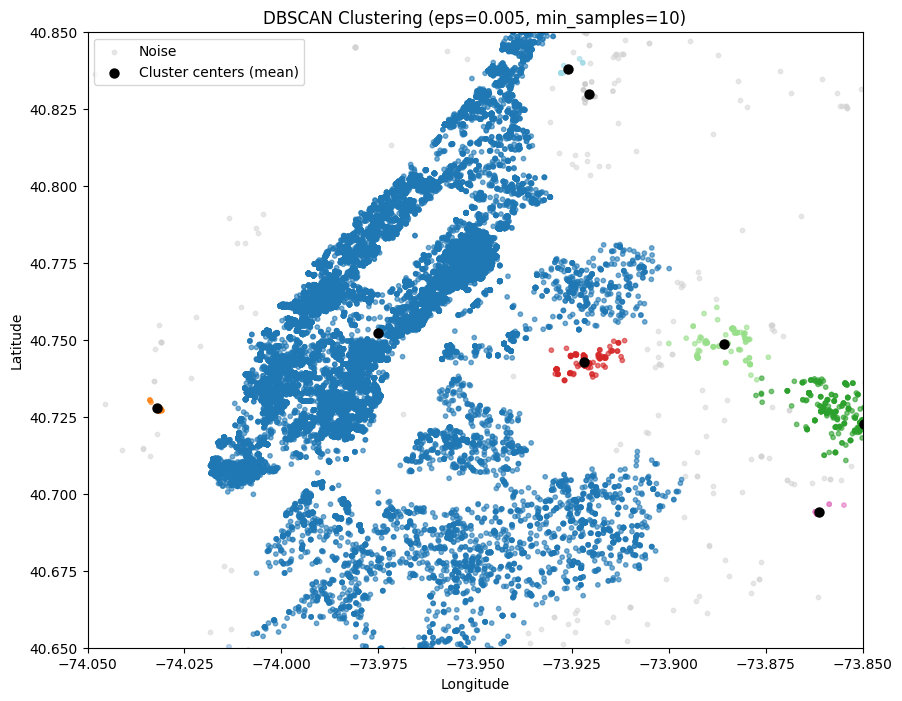

In [31]:
centers = df_train_filtered[df_train_filtered['cluster'] != -1].groupby('cluster')[['longitude', 'latitude']].mean()

plt.figure(figsize=(10, 8))

mask_noise = df_train_filtered['cluster'] == -1
plt.scatter(
    df_train_filtered.loc[mask_noise, 'longitude'],
    df_train_filtered.loc[mask_noise, 'latitude'],
    c='lightgray',
    s=10,
    alpha=0.5,
    label='Noise'
)

mask_clusters = ~mask_noise
plt.scatter(
    df_train_filtered.loc[mask_clusters, 'longitude'],
    df_train_filtered.loc[mask_clusters, 'latitude'],
    c=df_train_filtered.loc[mask_clusters, 'cluster'],
    cmap='tab20',
    s=10,
    alpha=0.6
)

plt.scatter(
    centers['longitude'],
    centers['latitude'],
    c='black',
    marker='o',
    s=30,
    linewidths=2,
    label='Cluster centers (mean)'
)

plt.xlim(-74.05, -73.85)
plt.ylim(40.65, 40.85)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("DBSCAN Clustering (eps=0.005, min_samples=10)")
plt.legend()
plt.show()

Hyperparameter selection

In [32]:
X = df_train_filtered[['longitude', 'latitude']].values

# Hyperparameters grid
# eps_values = np.linspace(0.001, 0.01, 10)
# min_samples_values = [5, 10]

eps_values = [0.005, 0.001]
min_samples_values = [5, 10]

results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = CustomDBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X)

        if len(set(labels)) > 1 and -1 in labels and len(set(labels)) > 2:
            score = silhouette_score(X, labels)
        elif len(set(labels)) > 1:
            score = silhouette_score(X, labels)
        else:
            score = None

        results.append({
            "eps": eps,
            "min_samples": min_samples,
            "n_clusters": len(set(labels)) - (1 if -1 in labels else 0),
            "silhouette": score
        })

results_df = pd.DataFrame(results)
results_df.sort_values(by="silhouette", ascending=False).style.apply(
    lambda row: ['font-weight: bold' if row.name == results_df.sort_values(by="silhouette", ascending=False).index[0] else '' for _ in row],
    axis=1
)

,eps,min_samples,n_clusters,silhouette
1,0.005000,10,20,-0.051402
0,0.005000,5,39,-0.119052
3,0.001000,10,298,-0.132999
2,0.001000,5,507,-0.169961


Lasso for prediction "Price" (20 features + "cluster" + "interest_level" + "badrooms" + "bathrooms")

In [33]:
X_train = df_train_filtered.drop(["building_id", "created", "description", "display_address", "latitude", "listing_id",
                                  "longitude", "manager_id", "photos", "price", "street_address"], axis=1).fillna(-1)
y_train = df_train_filtered["price"]

In [34]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)

In [35]:
lasso = Lasso(max_iter=10000, random_state=42)

param_grid = {
    "alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10]
}

grid = GridSearchCV(
    lasso,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=Lasso(max_iter=10000, random_state=42), n_jobs=-1,
             param_grid={'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]},
             scoring='neg_mean_squared_error')

In [36]:
best_lasso = grid.best_estimator_
best_lasso.fit(X_train_scaled, y_train)

feature_importance = pd.DataFrame({
    "name": X_train.columns,
    "importance": abs(best_lasso.coef_)
}).sort_values(by="importance", ascending=True)

feature_importance.set_index("name", inplace=True)
(
    feature_importance
    .style
    .apply(
        lambda row: ['color: yellow' if row.name == "cluster" else '' for _ in row],
        axis=1
    )
    .map_index(
        lambda key: 'color: yellow' if key == "cluster" else '',
        axis="index"
    )
)

,importance
name,
pre-war,19.062785
newconstruction,23.502686
roofdeck,79.378795
swimmingpool,99.064977
outdoorspace,137.510381
dishwasher,148.053953
catsallowed,173.176746
balcony,229.275588
hardwoodfloors,240.129905


Comparing with results for sklearn DBScan

In [37]:
dbscan = DBSCAN(eps=0.005, min_samples=10)
dbscan.fit(df_train_filtered[['longitude', 'latitude']])

df_train_filtered['cluster'] = dbscan.labels_

mask = df_train_filtered['cluster'] != -1
X = df_train_filtered.loc[mask, ['longitude', 'latitude']]
labels = df_train_filtered.loc[mask, 'cluster']

if len(set(labels)) > 1:
    sil_score = silhouette_score(X, labels)
    display(Markdown(f"**Silhouette Score: {sil_score:.3f}**"))
else:
    print("Not enough clusters for calculating silhouette score")

**Silhouette Score: -0.044**

__Task_5 - Aglomerative Clustering__

Implementation of custom Agglomerative clustering algorithm

In [38]:
class CustomAgglomerative:
    def __init__(self, n_clusters=2):
        self.n_clusters = n_clusters
        self.labels_ = None

    def _distance(self, X, a, b):
        return np.sqrt(np.sum((X[a] - X[b]) ** 2))

    def _cluster_distance(self, X, cluster_a, cluster_b):
        min_dist = float("inf")
        for i in cluster_a:
            for j in cluster_b:
                d = self._distance(X, i, j)
                if d < min_dist:
                    min_dist = d
        return min_dist

    def fit(self, X):
        # step1: Инициализация отдельной точки как кластера
        X = np.array(X)
        n = len(X)
        clusters = [[i] for i in range(n)]

        # step2: Ищем два ближайших кластера, linkage='single'
        while len(clusters) > self.n_clusters:
            min_dist = float("inf")
            to_merge = (None, None)

            for i in range(len(clusters)):
                for j in range(i + 1, len(clusters)):
                    d = self._cluster_distance(X, clusters[i], clusters[j])
                    if d < min_dist:
                        min_dist = d
                        to_merge = (i, j)

            # step3: Объединяем метки
            i, j = to_merge
            clusters[i] = clusters[i] + clusters[j]
            del clusters[j]

        # step4: Формируем метки
        self.labels_ = np.empty(n, dtype=int)
        for cluster_id, cluster in enumerate(clusters):
            for idx in cluster:
                self.labels_[idx] = cluster_id
        return self

    def fit_predict(self, X):
        self.fit(X)
        return self.labels_

CustomAglomerative by longitude, latitude

In [39]:
start = time.time()
connectivity = kneighbors_graph(df_train_filtered[['longitude', 'latitude']], n_neighbors=20, include_self=False)
agglomerative = AgglomerativeClustering(n_clusters=30, linkage="ward", connectivity=connectivity)
agglomerative.fit(df_train_filtered[['longitude', 'latitude']])
end = time.time()

df_train_filtered['cluster'] = agglomerative.labels_
print("Agglomerative time:", end - start)

Agglomerative time: 16.70564317703247


Visualization

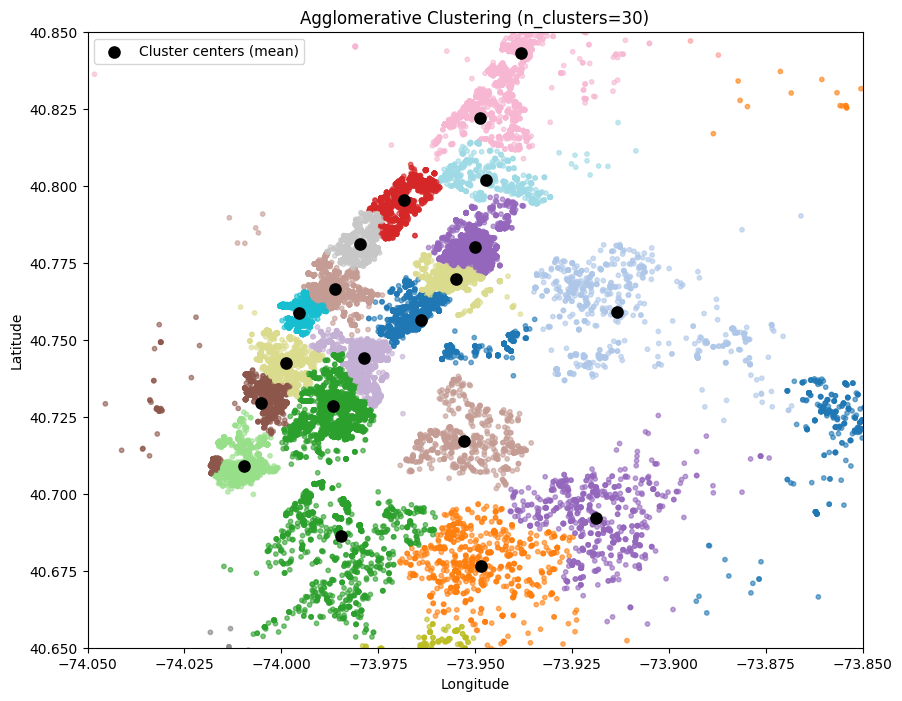

In [40]:
clusters = agglomerative.fit_predict(df_train_filtered[["longitude", "latitude"]].values)
df_train_filtered["cluster"] = clusters
centers = df_train_filtered.groupby("cluster")[["longitude", "latitude"]].mean().reset_index()

plt.figure(figsize=(10, 8))

plt.scatter(
    df_train_filtered["longitude"],
    df_train_filtered["latitude"],
    c=df_train_filtered["cluster"],
    cmap="tab20",
    s=10,
    alpha=0.6
)

plt.scatter(
    centers["longitude"],
    centers["latitude"],
    c="black",
    marker="o",
    s=50,
    linewidths=2,
    label="Cluster centers (mean)"
)

plt.xlim(-74.05, -73.85)
plt.ylim(40.65, 40.85)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Agglomerative Clustering (n_clusters=30)")
plt.legend()
plt.show()

In [54]:
labels_agg = agglomerative.fit_predict(df_train_filtered[['longitude', 'latitude']].values)
sil_score = silhouette_score(df_train_filtered[['longitude', 'latitude']].values, labels_agg)
display(Markdown(f"**Silhouette Score: {sil_score:.3f}**"))

**Silhouette Score: 0.423**

Lasso for prediction "Price" (20 features + "cluster" + "interest_level" + "badrooms" + "bathrooms")

In [41]:
X_train = df_train_filtered.drop(["building_id", "created", "description", "display_address", "latitude", "listing_id",
                                  "longitude", "manager_id", "photos", "price", "street_address"], axis=1).fillna(-1)
y_train = df_train_filtered["price"]

In [42]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)

In [43]:
lasso = Lasso(max_iter=10000, random_state=42)

param_grid = {
    "alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10]
}

grid = GridSearchCV(
    lasso,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=Lasso(max_iter=10000, random_state=42), n_jobs=-1,
             param_grid={'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]},
             scoring='neg_mean_squared_error')

In [44]:
best_lasso = grid.best_estimator_
best_lasso.fit(X_train_scaled, y_train)

feature_importance = pd.DataFrame({
    "name": X_train.columns,
    "importance": abs(best_lasso.coef_)
}).sort_values(by="importance", ascending=True)

feature_importance.set_index("name", inplace=True)
(
    feature_importance
    .style
    .apply(
        lambda row: ['color: yellow' if row.name == "cluster" else '' for _ in row],
        axis=1
    )
    .map_index(
        lambda key: 'color: yellow' if key == "cluster" else '',
        axis="index"
    )
)

,importance
name,
newconstruction,5.959165
pre-war,22.330108
swimmingpool,70.390355
roofdeck,74.565597
dishwasher,132.265974
outdoorspace,142.000069
catsallowed,168.727006
balcony,228.750252
diningroom,236.364056


__Task_6 - Gaussian Mixture__

Implementation of custom GaussianMixture algorithm

In [45]:
class CustomGaussianMixture:
    def __init__(self, n_components=2, max_iter=100, tol=1e-4, random_state=None):
        self.n_components = n_components
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state

    def fit(self, X):
        np.random.seed(self.random_state)
        n_samples, n_features = X.shape

        # step1: Инициализация
        means = X[np.random.choice(n_samples, self.n_components, replace=False)]
        covariances = np.array([np.cov(X, rowvar=False)] * self.n_components)
        weights = np.ones(self.n_components) / self.n_components

        log_likelihood_old = None

        for iteration in range(self.max_iter):
            # step2: Вычисляем вероятности отношения к каждому кластеру для каждой точки
            responsibilities = np.zeros((n_samples, self.n_components))
            for k in range(self.n_components):
                responsibilities[:, k] = weights[k] * multivariate_normal.pdf(
                    X, mean=means[k], cov=covariances[k])
            responsibilities /= responsibilities.sum(axis=1, keepdims=True)

            # step3: Обновляем параметры
            Nk = responsibilities.sum(axis=0)
            weights = Nk / n_samples
            means = (responsibilities.T @ X) / Nk[:, np.newaxis]

            covariances = []
            for k in range(self.n_components):
                diff = X - means[k]
                cov = (responsibilities[:, k][:, np.newaxis] * diff).T @ diff / Nk[k]
                covariances.append(cov)
            covariances = np.array(covariances)

            # step4: log-likelihood
            log_likelihood = np.sum(np.log(np.sum(
              [weights[k] * multivariate_normal.pdf(X, means[k], covariances[k])
                for k in range(self.n_components)], axis=0)))

            if log_likelihood_old is not None and abs(log_likelihood - log_likelihood_old) < self.tol:
                break
            log_likelihood_old = log_likelihood

        self.means_ = means
        self.covariances_ = covariances
        self.weights_ = weights
        self.responsibilities_ = responsibilities

    def predict(self, X):
        n_samples = X.shape[0]
        responsibilities = np.zeros((n_samples, self.n_components))
        for k in range(self.n_components):
            responsibilities[:, k] = self.weights_[k] * multivariate_normal.pdf(
                X, mean=self.means_[k], cov=self.covariances_[k]
            )
        responsibilities /= responsibilities.sum(axis=1, keepdims=True)
        return np.argmax(responsibilities, axis=1)

GaussianMixture by longitude, latitude

In [46]:
start = time.time()
gmm = GaussianMixture(n_components=30, max_iter=100, tol=1e-4, random_state=42)
gmm.fit(df_train_filtered[['longitude', 'latitude']].values)
labels = gmm.predict(df_train_filtered[['longitude', 'latitude']].values)
end = time.time()

df_train_filtered['cluster'] = labels
print("Custom Gaussian Mixture time:", end - start)

Custom Gaussian Mixture time: 18.626506805419922


Visualization

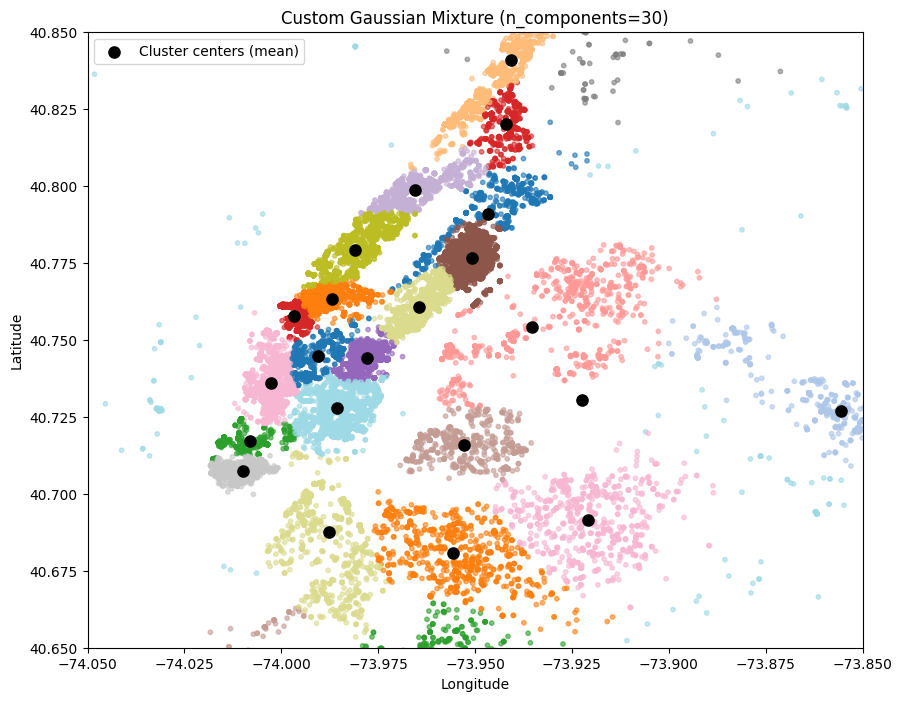

In [47]:
centers = df_train_filtered.groupby("cluster")[["longitude", "latitude"]].mean()

plt.figure(figsize=(10, 8))

plt.scatter(
    df_train_filtered["longitude"],
    df_train_filtered["latitude"],
    c=df_train_filtered["cluster"],
    cmap="tab20",
    s=10,
    alpha=0.6
)

plt.scatter(
    centers["longitude"],
    centers["latitude"],
    c="black",
    marker="o",
    s=50,
    linewidths=2,
    label="Cluster centers (mean)"
)

plt.xlim(-74.05, -73.85)
plt.ylim(40.65, 40.85)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Custom Gaussian Mixture (n_components=30)")
plt.legend()
plt.show()

In [55]:
labels_gmm = gmm.fit_predict(df_train_filtered[['longitude', 'latitude']].values)
sil_score = silhouette_score(df_train_filtered[['longitude', 'latitude']].values, labels_gmm)
display(Markdown(f"**Silhouette Score: {sil_score:.3f}**"))

**Silhouette Score: 0.397**

Lasso for prediction "Price" (20 features + "cluster" + "interest_level" + "badrooms" + "bathrooms")

In [48]:
X_train = df_train_filtered.drop(["building_id", "created", "description", "display_address", "latitude", "listing_id",
                                  "longitude", "manager_id", "photos", "price", "street_address"], axis=1).fillna(-1)
y_train = df_train_filtered["price"]

In [49]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)

In [50]:
lasso = Lasso(max_iter=10000, random_state=42)

param_grid = {
    "alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10]
}

grid = GridSearchCV(
    lasso,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=Lasso(max_iter=10000, random_state=42), n_jobs=-1,
             param_grid={'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]},
             scoring='neg_mean_squared_error')

In [51]:
best_lasso = grid.best_estimator_
best_lasso.fit(X_train_scaled, y_train)

feature_importance = pd.DataFrame({
    "name": X_train.columns,
    "importance": abs(best_lasso.coef_)
}).sort_values(by="importance", ascending=True)

feature_importance.set_index("name", inplace=True)
(
    feature_importance
    .style
    .apply(
        lambda row: ['color: yellow' if row.name == "cluster" else '' for _ in row],
        axis=1
    )
    .map_index(
        lambda key: 'color: yellow' if key == "cluster" else '',
        axis="index"
    )
)

,importance
name,
newconstruction,0.000000
pre-war,5.714734
roofdeck,62.753243
swimmingpool,82.816702
catsallowed,108.335950
outdoorspace,120.380484
dishwasher,129.454684
balcony,177.304201
diningroom,243.033282


__Task_7 - Application of algorithms with different parameters__

In this task need to try clustering with different features like 20 features + ["cluster", "interest_level", "bedrooms", "bathrooms"]. You can find this implementation in previous tasks.

__Task_8 - Comparing results of algorithms by parameters: time, complexity, score__

Algorithm complexity:
- K-means: time - O(n * k * d * i); memory - O(n + k)
- DBScan: time - O(n log n) - O(n^2); memory - O(n)
- Agglomerative: time - O(n^2 log n) - O(n^3); memory - O(n^2)
- Gaussian Mixture: time - O(n * k * d * i); memory - O(n + k*d^2)

Algorithm time (sec):
- K-means: 2.95
- DBScan: 46.16
- Agglomerative(sklearn): 16.7
- Gaussian Mixture(sklearn): 18.6

Custom algorithm score (silhouette):
- K-means (n_clusters=30): 0.48
- DBScan(eps=0.005, min_samples=10): -0.051
- Agglomerative(n_clusters=30): -
- Gaussian Mixture(n_clusters=30): -

Sklearn algorithm score (silhouette):
- K-means (n_clusters=30): 0.43
- DBScan(eps=0.005, min_samples=10): -0.044
- Agglomerative(n_clusters=30): 0.42
- Gaussian Mixture(n_clusters=30): 0.40

In [57]:
data = {
    "Algorithm": ["K-means", "DBSCAN", "Agglomerative(sklearn)", "Gaussian Mixture(sklearn)"],
    "Parameters": ["n_clusters=30", "eps=0.005, min_samples=10", "n_clusters=30", "n_components=30, max_iter=100, tol=1e-3"],
    "Time (sec)": [2.95, 46.16, 16.7, 18.6],
    "Scores": ["Silhouette = 0.48, Distortion = 4.27", "Silhouette = -0.051", "Silhouette = 0.42", "Silhouette = 0.40"],
    "Time Complexity": ["O(n*k*d*i)", "O(n log n – n^2)", "O(n^2 log n – n^3)", "O(n*k*d*i)"],
    "Memory Complexity": ["O(n + k)", "O(n)", "O(n^2)", "O(n + k*d^2)"]
}

df = pd.DataFrame(data)
print(tabulate(df, headers='keys', tablefmt='fancy_grid', showindex=False, stralign='center', numalign='center'))

╒═══════════════════════════╤═════════════════════════════════════════╤══════════════╤══════════════════════════════════════╤════════════════════╤═════════════════════╕
│         Algorithm         │               Parameters                │  Time (sec)  │                Scores                │  Time Complexity   │  Memory Complexity  │
╞═══════════════════════════╪═════════════════════════════════════════╪══════════════╪══════════════════════════════════════╪════════════════════╪═════════════════════╡
│          K-means          │              n_clusters=30              │     2.95     │ Silhouette = 0.48, Distortion = 4.27 │     O(n*k*d*i)     │      O(n + k)       │
├───────────────────────────┼─────────────────────────────────────────┼──────────────┼──────────────────────────────────────┼────────────────────┼─────────────────────┤
│          DBSCAN           │        eps=0.005, min_samples=10        │    46.16     │         Silhouette = -0.051          │  O(n log n – n^2)  │        O

# __Bonus_part__

__Task_1__

__Task_2__

__Task_3__